<a href="https://colab.research.google.com/github/Bassendiaye/mes_notebooks/blob/main/classification_Cat_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DEMO**

In [ ]:
#Installation des bibliothèques nécessaires

!pip install torch torchvision transformers datasets timm

In [ ]:
import os
import torch
import zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import ViTForImageClassification, ViTFeatureExtractor
import torch.nn as nn
import torch.optim as optim
from google.colab import files

## **Téléversement et extraction du dataset**

In [ ]:
# Téléverser et décompresser les données dans Colab
print("Téléversez le fichier ZIP contenant les dossiers 'dog' et 'cat'")
uploaded = files.upload()

Téléversez le fichier ZIP contenant les dossiers 'dog' et 'cat'


Saving Classification_d_image.zip to Classification_d_image.zip


## **Récupèration et décrompression du fichier ZIP téléversé**

In [ ]:
# Décompresser le fichier ZIP
zip_path = list(uploaded.keys())[0]  # Récupérer le nom du fichier téléversé
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

## **Définition du chemin des dossiers**

In [ ]:
data_dir = "/content/data/Classification_d_image"

## **Chargement des images et labels**

In [ ]:
def load_image_paths_and_labels(data_dir):
    classes = ["Dog", "Cat"]
    image_paths = []
    labels = []

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Avertissement : {class_dir} n'existe pas")
            continue

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            if os.path.isfile(img_path):
                image_paths.append(img_path)
                labels.append(label)  # 0 pour "dog", 1 pour "cat"

    return image_paths, labels
image_paths, labels = load_image_paths_and_labels(data_dir)

## **Division des données en train et test**

In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.2, random_state=42)

## **Prétraitement des images**

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Redimensionne l'image à 224x224
    transforms.ToTensor(),  # Convertit en tenseur PyTorch
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalisation
])

## **Définition du Dataset**

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")  # Charge l'image
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)  # Applique les transformations
        return image, label

## **Création des DataLoaders**

In [ ]:
train_dataset = CustomImageDataset(train_paths, train_labels, transform=transform)
test_dataset = CustomImageDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## **Chargement du modèle Vision Transformer pré-entraîné**

In [ ]:
model_name = "google/vit-base-patch16-224"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


## **Chargement le modèle ViT et adaptation de la classification avec nos 2 classes (Dog et Cat)**

In [ ]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,  # 2 classes : Dog et Cat
    ignore_mismatched_sizes=True
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Utilisation du GPU**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cpu


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

## **Optimiseur et fonction de perte**

In [ ]:
# Définition de l'optimiseur et de la fonction de perte
optimiseur = optim.Adam(model.parameters(), lr=1e-4)
f_perte = nn.CrossEntropyLoss()

## **Entraînement du modèle**

In [ ]:
# Entraînement
epochs = 2
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Adapter le format des données pour ViT
        inputs = {"pixel_values": images}

        optimiseur.zero_grad()
        outputs = model(**inputs).logits
        loss = f_perte(outputs, labels)
        loss.backward()
        optimiseur.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader)}")

100%|██████████| 26/26 [26:31<00:00, 61.20s/it]


Epoch 1/2, Loss: 0.12316117129431894


100%|██████████| 26/26 [26:17<00:00, 60.68s/it]

Epoch 2/2, Loss: 0.01662862072183858


## **Evaluation du modèle**

In [ ]:
import matplotlib.pyplot as plt
import torch

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    all_losses = []

    f_perte = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            inputs = {"pixel_values": images}
            outputs = model(**inputs).logits

            loss = f_perte(outputs, labels)  # Calculer la loss
            all_losses.append(loss.item())

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    return accuracy, all_losses

epochs = 5
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        inputs = {"pixel_values": images}

        optimiseur.zero_grad()
        outputs = model(**inputs).logits
        loss = f_perte(outputs, labels)
        loss.backward()
        optimiseur.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    test_acc, test_loss = evaluate_model(model, test_loader, device)

    train_losses.append(train_loss)
    test_losses.append(sum(test_loss) / len(test_loss))
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Test Accuracy: 99.30%
Epoch 1/5 | Train Loss: 0.0004 | Train Acc: 100.00% | Test Acc: 99.30%
Test Accuracy: 99.40%
Epoch 2/5 | Train Loss: 0.0001 | Train Acc: 100.00% | Test Acc: 99.40%
Test Accuracy: 99.30%
Epoch 3/5 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 99.30%


## **Courbe d'apprentissage**

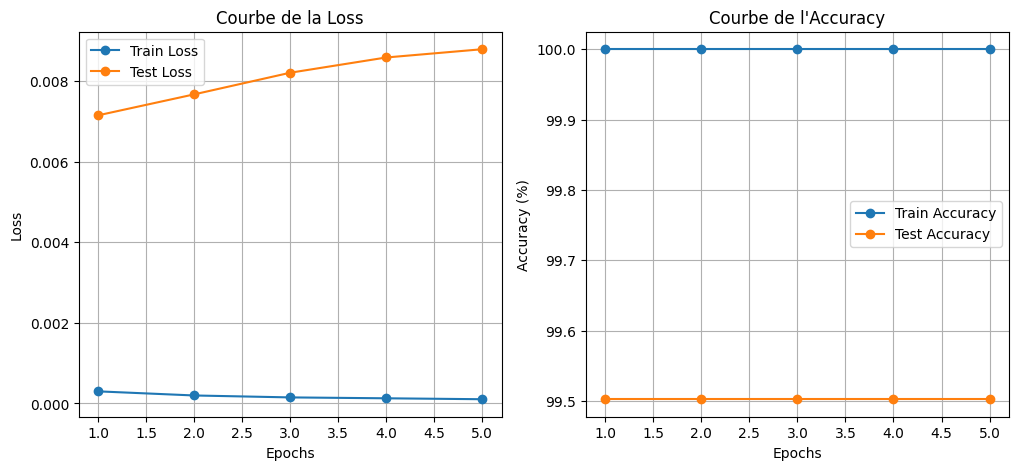

In [ ]:
def plot_learning_curve(train_losses, test_losses, train_accs, test_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Graphique de la loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs, test_losses, label="Test Loss", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Courbe de la Loss")
    plt.legend()
    plt.grid()

    # Graphique de l'accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
    plt.plot(epochs, test_accs, label="Test Accuracy", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Courbe de l'Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

plot_learning_curve(train_losses, test_losses, train_accs, test_accs)

# **Prédiction**

In [ ]:
# Fonction de prédiction
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs).logits
    predicted_class_idx = outputs.argmax(-1).item()
    classes = ["Dog", "Cat"]
    return classes[predicted_class_idx]

# Téléverser une image
uploaded = files.upload()

# Obtenir le nom du fichier téléversé
image_name = "image.png"

# Faire la prédiction
prediction = predict_image(image_name)

# Afficher la prédiction
print(f"Prediction for {image_name}: {prediction}")

Saving image.png to image.png
Prediction for image.png: Cat


In [ ]:
from PIL import Image

# Ouvrir l'image
image = Image.open('181.jpg')

# Obtenir la résolution (dimensions) de l'image
largeur, hauteur = image.size

print(f"La résolution de l'image est {largeur}x{hauteur} pixels.")

La résolution de l'image est 326x45 pixels.
